In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

I0000 00:00:1780910456.828997   42891 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780910456.899460   42891 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780910460.039681   42891 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780910467.455821   42891 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [2]:
X,y=make_classification(n_samples=100000,n_informative=10,random_state=2022)

In [3]:
#splitting into the training and testing data
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=274)
#PRINTING THE SHAPES OF THE TRAINING AND TESTING DATA AND SHAPES OF THE LABELS

print("Training data shape:", X_train.shape, y_train.shape)
print("Testing data shape:", X_test.shape, y_test.shape)

Training data shape: (80000, 20) (80000,)
Testing data shape: (20000, 20) (20000,)


In [4]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation="relu", input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history = model.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test), verbose=1)

/workspaces/AI-ML-Day01/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1780910493.356394   42891 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9030 - loss: 0.2359 - val_accuracy: 0.9417 - val_loss: 0.1597
Epoch 2/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9519 - loss: 0.1415 - val_accuracy: 0.9572 - val_loss: 0.1291
Epoch 3/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9608 - loss: 0.1201 - val_accuracy: 0.9629 - val_loss: 0.1141
Epoch 4/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9665 - loss: 0.1071 - val_accuracy: 0.9677 - val_loss: 0.1018
Epoch 5/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9695 - loss: 0.0994 - val_accuracy: 0.9722 - val_loss: 0.0951
Epoch 6/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9718 - loss: 0.0948 - val_accuracy: 0.9733 - val_loss: 0.0924
Epoch 7/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9729 - loss: 0.0919 - val_accuracy: 0.9732 - val_loss: 0.0930
Epoch 8/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9743 - loss: 0.0895 -

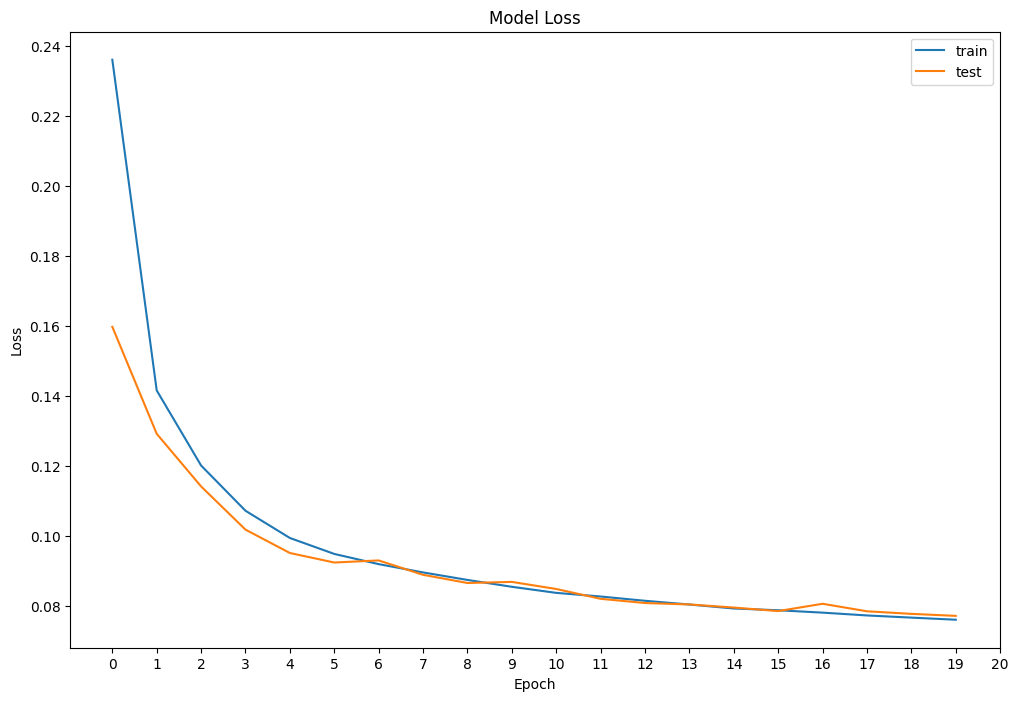

In [5]:
# plot the loss f the model
fig, ax = plt.subplots(figsize=(12, 8))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(np.arange(0, 21, 1))
plt.legend(['train', 'test'], loc='upper right')
plt.show()